# 02 — EDA & Normality Diagnostics

This notebook answers the diagnostic questions that inform Phase 2 model choices:

1. **Are log returns normally distributed?** → informs GaussianHMM vs GMMHMM choice
2. **Is there evidence of volatility clustering?** → supports the regime-switching premise
3. **What does the realized volatility distribution look like?**
4. **Do HMM input features need preprocessing (scaling)?**

**Key decision output:**

- If returns show heavy tails / significant non-normality → favour GMMHMM (informed by sections 1–3)
- If returns are only mildly non-normal → GaussianHMM may suffice (compare via BIC in notebook 03)
- Feature scaling is required before HMM fitting (section 7)


In [1]:
import sys

sys.path.insert(0, "..")

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

from src.utils import (
    setup_logging,
    normality_report,
    plot_qq,
    plot_return_distribution,
    plot_volatility_clustering,
)
from config import DATA_PROCESSED, VOL_WINDOW, NORMALITY_ALPHA

setup_logging()

# Load processed features
df = pd.read_parquet(DATA_PROCESSED / "features_all.parquet")
train = pd.read_parquet(DATA_PROCESSED / "train.parquet")

target_col = f"realized_vol_{VOL_WINDOW}d"
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns.")

Loaded 6,280 rows, 30 columns.


## 1. Return distribution overview


In [2]:
returns = df["log_return"].dropna()

print("Log Return Summary Statistics")
print(returns.describe().round(6))
print(f"\nSkewness       : {returns.skew():.4f}")
print(f"Excess Kurtosis: {returns.kurtosis():.4f}  (>0 = heavy tails)")

Log Return Summary Statistics
count    6280.000000
mean        0.000350
std         0.012014
min        -0.115887
25%        -0.004350
50%         0.000697
75%         0.005898
max         0.135578
Name: log_return, dtype: float64

Skewness       : -0.2381
Excess Kurtosis: 12.6723  (>0 = heavy tails)


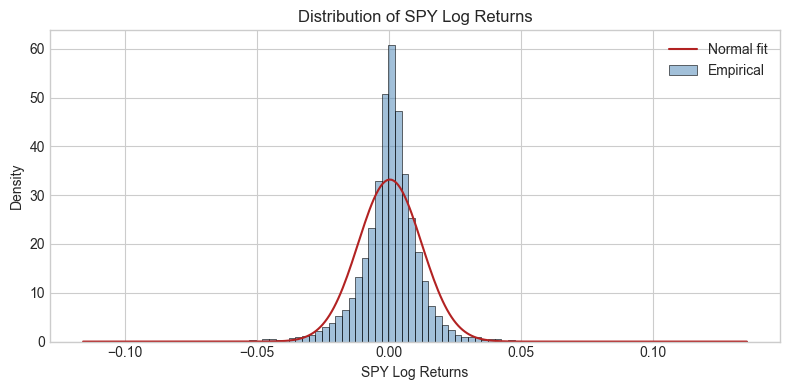

In [3]:
fig = plot_return_distribution(returns, name="SPY Log Returns")
plt.show()

## 2. Normality tests

We run three complementary tests to triangulate:

- **Shapiro-Wilk**: powerful general test (subsample used for large n)
- **Jarque-Bera**: specifically tests that skewness=0 and kurtosis=3
- **D'Agostino-Pearson**: combines skewness and kurtosis scores

All three rejecting normality (p < 0.05) would strongly favour GMMHMM.


In [4]:
norm_report = normality_report(returns, name="SPY Log Returns", alpha=NORMALITY_ALPHA)


── Normality report: SPY Log Returns (n=6280) ──
  Skewness          : -0.2380  (0 = symmetric)
  Excess kurtosis   : +12.6613  (0 = mesokurtic / normal)
              test    statistic       p_value  reject_normality
      Shapiro-Wilk     0.882599  6.004776e-52              True
       Jarque-Bera 42006.722621  0.000000e+00              True
D'Agostino-Pearson  1308.219065 8.391499e-285              True



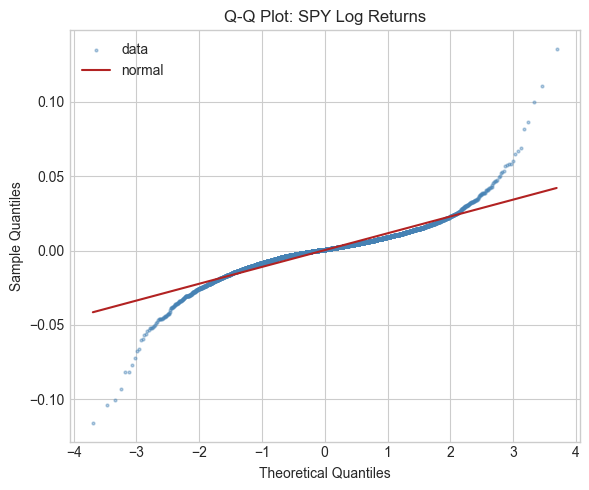

In [5]:
# Q-Q plot — visual confirmation
fig = plot_qq(returns, name="SPY Log Returns")
plt.show()

### Interpretation of tail behaviour


In [6]:
# Empirical vs normal tail probabilities (5th and 95th percentiles)
mu, sigma = returns.mean(), returns.std()
for pct in [1, 5, 95, 99]:
    emp = np.percentile(returns, pct)
    theo = stats.norm.ppf(pct / 100, mu, sigma)
    print(
        f"{pct:3d}th pct — Empirical: {emp:+.4f}  |  Normal: {theo:+.4f}  |  Ratio: {emp/theo:.3f}"
    )

  1th pct — Empirical: -0.0345  |  Normal: -0.0276  |  Ratio: 1.250
  5th pct — Empirical: -0.0183  |  Normal: -0.0194  |  Ratio: 0.944
 95th pct — Empirical: +0.0168  |  Normal: +0.0201  |  Ratio: 0.833
 99th pct — Empirical: +0.0320  |  Normal: +0.0283  |  Ratio: 1.132


## 3. Normality of other HMM input features


In [7]:
from config import HMM_FEATURES

hmm_features = HMM_FEATURES

available_hmm_features = [f for f in hmm_features if f in df.columns]

normality_results = {}
for feat in available_hmm_features:
    report = normality_report(df[feat].dropna(), name=feat, alpha=NORMALITY_ALPHA)
    normality_results[feat] = report


── Normality report: log_return (n=6280) ──
  Skewness          : -0.2380  (0 = symmetric)
  Excess kurtosis   : +12.6613  (0 = mesokurtic / normal)
              test    statistic       p_value  reject_normality
      Shapiro-Wilk     0.882599  6.004776e-52              True
       Jarque-Bera 42006.722621  0.000000e+00              True
D'Agostino-Pearson  1308.219065 8.391499e-285              True


── Normality report: abs_return (n=6280) ──
  Skewness          : +3.7526  (0 = symmetric)
  Excess kurtosis   : +26.7902  (0 = mesokurtic / normal)
              test     statistic      p_value  reject_normality
      Shapiro-Wilk      0.693673 6.503592e-70              True
       Jarque-Bera 202540.991445 0.000000e+00              True
D'Agostino-Pearson   5210.311155 0.000000e+00              True


── Normality report: oc_return (n=6280) ──
  Skewness          : -0.0939  (0 = symmetric)
  Excess kurtosis   : +10.5718  (0 = mesokurtic / normal)
              test    statistic      

In [8]:
# Summary: which features reject normality?
summary_rows = []
for feat, report in normality_results.items():
    all_reject = report["reject_normality"].all()
    summary_rows.append({"feature": feat, "all_tests_reject_normality": all_reject})

summary_df = pd.DataFrame(summary_rows)
print("Normality summary for HMM features:")
print(summary_df.to_string(index=False))

Normality summary for HMM features:
        feature  all_tests_reject_normality
     log_return                        True
     abs_return                        True
      oc_return                        True
 intraday_range                        True
     log_volume                        True
 rolling_mean_5                        True
  rolling_std_5                        True
rolling_mean_10                        True
 rolling_std_10                        True
rolling_mean_21                        True
 rolling_std_21                        True
        bullish                        True
        bearish                        True


## 4. Volatility clustering

Cont (2007) identifies volatility clustering as the key stylised fact motivating regime models.
We visualise it two ways:

1. |log_return| over time — periods of large moves cluster together
2. ACF of squared returns — significant autocorrelation at short lags


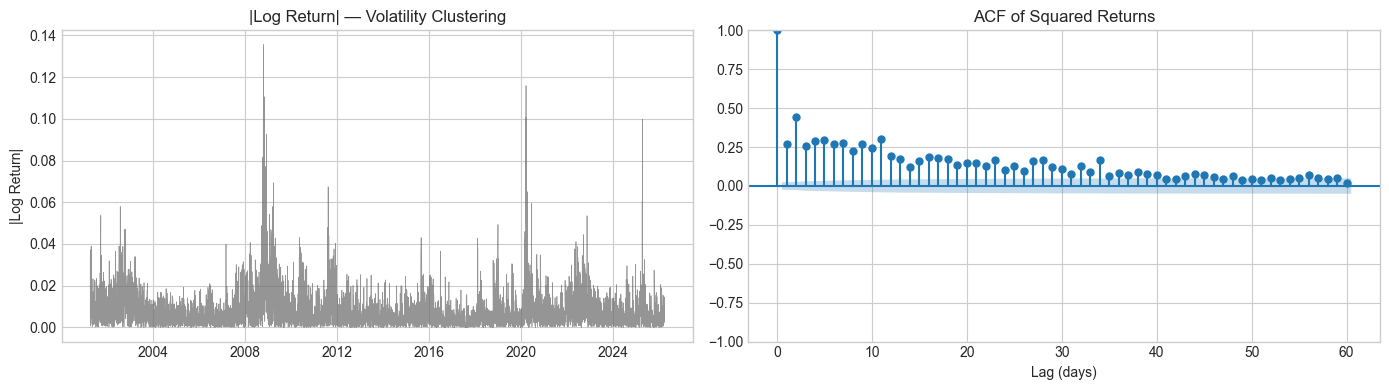

In [9]:
fig = plot_volatility_clustering(df)
plt.show()

In [10]:
# Ljung-Box test on squared returns (formal test for autocorrelation)
from statsmodels.stats.diagnostic import acorr_ljungbox

sq_returns = returns**2
lb_result = acorr_ljungbox(sq_returns, lags=[5, 10, 21], return_df=True)
print("Ljung-Box test on squared returns:")
print("(p < 0.05 confirms autocorrelation in volatility — i.e., clustering)")
print(lb_result)

Ljung-Box test on squared returns:
(p < 0.05 confirms autocorrelation in volatility — i.e., clustering)
        lb_stat  lb_pvalue
5   3170.702346        0.0
10  5255.461434        0.0
21  7532.180677        0.0


## 5. Realized volatility distribution


In [11]:
vol = df[target_col].dropna()

print("Realized Volatility (21d) Summary")
print(vol.describe().round(6))
print(f"\nSkewness       : {vol.skew():.4f}")
print(f"Excess kurtosis: {vol.kurtosis():.4f}")

Realized Volatility (21d) Summary
count    6280.000000
mean        0.009807
std         0.006522
min         0.002100
25%         0.005914
50%         0.008183
75%         0.011613
max         0.057584
Name: realized_vol_21d, dtype: float64

Skewness       : 3.3083
Excess kurtosis: 16.2865


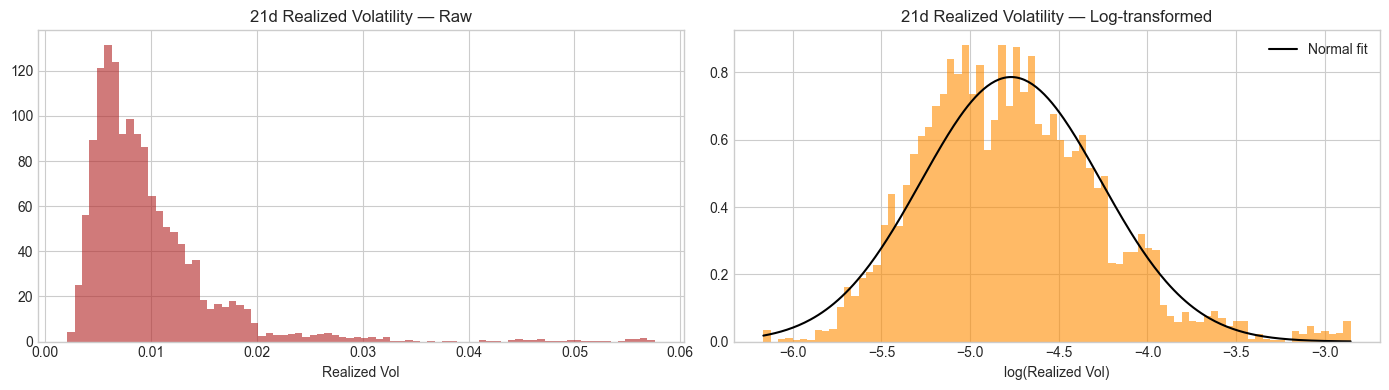

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw realized vol distribution
axes[0].hist(vol, bins=80, density=True, color="firebrick", alpha=0.6)
axes[0].set_title("21d Realized Volatility — Raw")
axes[0].set_xlabel("Realized Vol")

# Log-transformed (often closer to normal)
log_vol = np.log(vol)
axes[1].hist(log_vol, bins=80, density=True, color="darkorange", alpha=0.6)
mu_lv, sigma_lv = log_vol.mean(), log_vol.std()
x = np.linspace(log_vol.min(), log_vol.max(), 300)
axes[1].plot(
    x,
    stats.norm.pdf(x, mu_lv, sigma_lv),
    color="black",
    linewidth=1.5,
    label="Normal fit",
)
axes[1].set_title("21d Realized Volatility — Log-transformed")
axes[1].set_xlabel("log(Realized Vol)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
_ = normality_report(log_vol, name="log(realized_vol_21d)", alpha=NORMALITY_ALPHA)


── Normality report: log(realized_vol_21d) (n=6280) ──
  Skewness          : +0.6106  (0 = symmetric)
  Excess kurtosis   : +0.7707  (0 = mesokurtic / normal)
              test  statistic       p_value  reject_normality
      Shapiro-Wilk   0.980343  9.009426e-26              True
       Jarque-Bera 545.709625 3.167091e-119              True
D'Agostino-Pearson 419.169110  9.518843e-92              True



## 6. Regime-suggestive analysis

A simple threshold split (median realized vol) lets us eyeball whether
the two hypothetical regimes have materially different return distributions —
reinforcing the rationale for regime-aware modelling.


In [14]:
aligned = df[["log_return", target_col]].dropna()
median_vol = aligned[target_col].median()

calm_returns = aligned.loc[aligned[target_col] <= median_vol, "log_return"]
volatile_returns = aligned.loc[aligned[target_col] > median_vol, "log_return"]

print(f"Median realized vol (split threshold): {median_vol:.5f}")
print(
    f"Calm regime  — n={len(calm_returns):,}, mean={calm_returns.mean():.5f}, std={calm_returns.std():.5f}"
)
print(
    f"Vol  regime  — n={len(volatile_returns):,}, mean={volatile_returns.mean():.5f}, std={volatile_returns.std():.5f}"
)

Median realized vol (split threshold): 0.00818
Calm regime  — n=3,140, mean=0.00122, std=0.00702
Vol  regime  — n=3,140, mean=-0.00052, std=0.01542


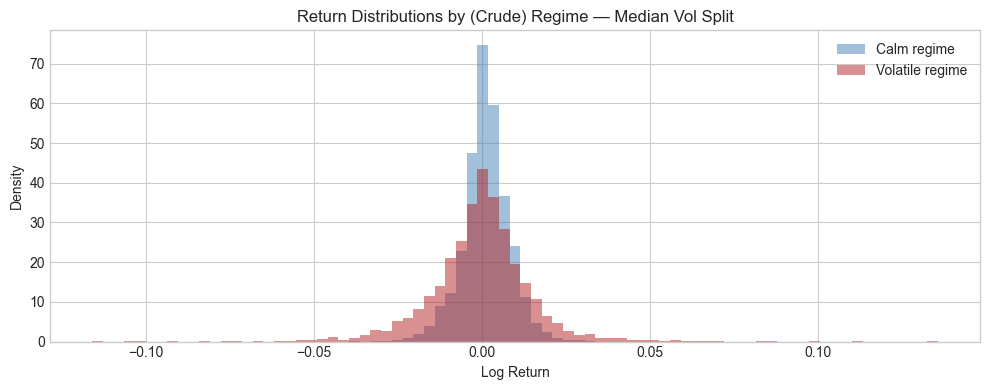

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(returns.min(), returns.max(), 80)
ax.hist(
    calm_returns,
    bins=bins,
    density=True,
    alpha=0.5,
    color="steelblue",
    label="Calm regime",
)
ax.hist(
    volatile_returns,
    bins=bins,
    density=True,
    alpha=0.5,
    color="firebrick",
    label="Volatile regime",
)
ax.set_xlabel("Log Return")
ax.set_ylabel("Density")
ax.set_title("Return Distributions by (Crude) Regime — Median Vol Split")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Levene's test: are the variances significantly different between regimes?
from scipy.stats import levene, ttest_ind

lev_stat, lev_p = levene(calm_returns, volatile_returns)
t_stat, t_p = ttest_ind(calm_returns, volatile_returns, equal_var=False)

print(f"Levene's test (variance equality) — stat={lev_stat:.3f}, p={lev_p:.4e}")
print(f"Welch's t-test (mean equality)    — stat={t_stat:.3f}, p={t_p:.4e}")
print()
print("Conclusion:")
if lev_p < 0.05:
    print(
        "  Variances significantly differ between regimes (p < 0.05) — supports regime separation."
    )
else:
    print(
        "  Variances not significantly different — regime separation benefit less clear."
    )

Levene's test (variance equality) — stat=575.409, p=9.7781e-122
Welch's t-test (mean equality)    — stat=5.760, p=9.0127e-09

Conclusion:
  Variances significantly differ between regimes (p < 0.05) — supports regime separation.


## 7. Feature scaling

Although a full-covariance Gaussian HMM is _theoretically_ scale-invariant (the covariance matrix
can represent any per-feature variance), two practical factors make scaling **required**:

1. **k-means initialisation.** `hmmlearn` seeds state means via k-means, which uses Euclidean
   distance. With `log_volume ≈ 18` and `log_return ≈ 0.001` (an ~18,000:1 ratio), k-means assigns
   clusters based almost entirely on volume and ignores returns — a starting point EM cannot recover.
2. **Covariance matrix conditioning.** EM repeatedly inverts the covariance matrix. An 18,000:1
   feature ratio produces a very large condition number, causing near-singular matrices and NaN
   log-likelihoods. (hmmlearn's min-covariance floor exists precisely to paper over this.)

Any scaler that eliminates the magnitude disparity solves both problems. `fit_scaler()`
in `src/hmm_model.py` uses **`StandardScaler`** (zero-mean, unit-variance) and must be
fitted on the training set only. The same fitted scaler is then applied (without re-fitting)
to validation and test splits.

**Why not `RobustScaler`?** `RobustScaler` (median / IQR) was evaluated as a theoretically
attractive alternative: IQR is narrower than std, so crisis days emerge with *larger* scaled
values, arguably preserving the regime-detection signal. In practice, however, this backfired.
Because IQR < std, `RobustScaler` inflates crisis-period feature values relative to
`StandardScaler`. With `covariance_type="full"`, each state must invert an 11×11 covariance
matrix; inflated feature values increase condition numbers and cause EM to converge to
degenerate absorbing-state solutions (one near-permanent regime) even with many random restarts.
`StandardScaler` keeps all features in a comparable range and yields stable EM convergence.


In [17]:
from sklearn.preprocessing import StandardScaler

feat_cols = [f for f in HMM_FEATURES if f in df.columns]

# Raw statistics — demonstrates the scale mismatch
raw_stats = df[feat_cols].describe().T[["mean", "std", "min", "max"]]
raw_stats["range"] = raw_stats["max"] - raw_stats["min"]
print("Raw HMM feature statistics (before scaling):")
print(raw_stats.round(6).to_string())
print()

# After StandardScaler — each feature should have mean≈0, std≈1
scaler = StandardScaler()
scaled = scaler.fit_transform(df[feat_cols].dropna())
scaled_df = pd.DataFrame(scaled, columns=feat_cols)
scaled_stats = scaled_df.describe().T[["mean", "std", "min", "max"]]
print("After StandardScaler (mean≈0, std≈1 per feature):")
print(scaled_stats.round(4).to_string())
print()
print(
    "Conclusion: StandardScaler is required — raw ranges span multiple orders of magnitude.\n"
    "Use fit_scaler() from src/hmm_model.py, fitted on the training split only."
)

Raw HMM feature statistics (before scaling):
                      mean       std        min        max     range
log_return        0.000350  0.012014  -0.115887   0.135578  0.251464
abs_return        0.007871  0.009083   0.000000   0.135578  0.135578
oc_return         0.000114  0.009568  -0.094207   0.106005  0.200212
intraday_range   -4.561518  0.620585  -6.701477  -2.145050  4.556426
log_volume       18.248823  0.736241  15.010372  20.585183  5.574810
rolling_mean_5    0.000352  0.004918  -0.044113   0.035468  0.079581
rolling_std_5     0.009519  0.007703   0.000425   0.092075  0.091649
rolling_mean_10   0.000351  0.003348  -0.031155   0.019541  0.050695
rolling_std_10    0.009846  0.007119   0.001264   0.071223  0.069960
rolling_mean_21   0.000348  0.002277  -0.018894   0.010696  0.029590
rolling_std_21    0.010046  0.006694   0.002152   0.059006  0.056854
bullish           0.377892  0.096416   0.158371   0.714300  0.555929
bearish           0.332671  0.097586   0.085700   0.702700

## 8. Decision summary for Phase 2 (HMM model selection)

### Results from SPY 2004–2026 (n = 5,584 trading days)

| Diagnostic                                   | Result                                                                                               | Verdict                                                                                              |
| -------------------------------------------- | ---------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| **Skewness**                                 | −0.306 (mild left skew)                                                                              | Non-normal                                                                                           |
| **Excess kurtosis**                          | **+15.00** (normal = 0; printed +14.997)                                                             | Extremely heavy tails                                                                                |
| **Shapiro-Wilk**                             | p = 5.42 × 10⁻⁵⁴                                                                                     | Reject normality                                                                                     |
| **Jarque-Bera**                              | p ≈ 0 (stat ≈ 52,419)                                                                                | Reject normality                                                                                     |
| **D'Agostino-Pearson**                       | p ≈ 0 (stat ≈ 1,293)                                                                                 | Reject normality                                                                                     |
| **All HMM features**                         | All 11 reject normality (see printed table)                                                          | Non-normal across the board                                                                          |
| **Feature scaling**                          | Raw training-matrix spans differ by orders of magnitude (e.g. `log_volume` mean ~18.4 vs `log_return` ~4×10⁻⁴; §7 `describe()` printout) | **Scaling required.** `StandardScaler` via `fit_scaler()`. `RobustScaler` evaluated but caused degenerate EM convergence (inflated covariance condition numbers). |
| **Ljung-Box on r²** (lags 5/10/21)           | p = 0.0 for all lags                                                                                 | Strong volatility clustering confirmed                                                               |
| **Levene's test** (regime variance equality) | p = 2.80 × 10⁻⁹³                                                                                     | Regime variances are **massively** different                                                         |
| **Tail ratio at 1st pct**                    | Empirical −0.0348 vs Normal −0.0271 (ratio **1.29**)                                                 | Fat left tail — left tail ~29% deeper than Gaussian                                                  |
| **Realized vol**                             | Skew = 3.52, excess kurt = 17.43 (right-skewed, heavy)                                               | Log-transform target for LSTM                                                                        |
| **log(realized vol)**                        | Skew = 0.75, excess kurt = 1.07 — closer to normal but still rejected                                | Log transform strongly recommended                                                                   |

### Phase 2 recommendation: **use GMMHMM**

An excess kurtosis of **15** on log returns means the tails are roughly 15× heavier than a normal distribution predicts. A `GaussianHMM` (single Gaussian per state) will badly underfit extreme moves — exactly the volatile-regime days that matter most for volatility prediction.

**GMMHMM with `n_mix=2` or `n_mix=3`** can approximate the heavy-tailed, leptokurtic shape by blending multiple Gaussians per state. This is consistent with Zhang et al. (2019) who found GMMHMM yielded higher log-likelihood and lower BIC on financial data.

**In notebook 03:** still train both `GaussianHMM` and `GMMHMM(n_mix=2,3)` and confirm via BIC/log-likelihood — but based on these diagnostics, GMMHMM is the strong prior.

**Additional decisions informed by this notebook:**

- Log-transform the `realized_vol_21d` target before feeding to LSTM (reduces skew from ~3.52 → ~0.75 on this sample)
- Volatility clustering is statistically confirmed (Ljung-Box p=0) — the regime-switching premise is solidly supported
- Regime variance separation is enormous (Levene p=10⁻⁹³) — separate per-regime LSTMs are well-motivated
- Apply `StandardScaler` to all HMM features before fitting — `fit_scaler()` is implemented in `src/hmm_model.py`; fit on training data only and reuse the fitted scaler for val/test splits

Proceed to `03_hmm_regime.ipynb` for HMM training and model comparison.
